# 01 · Exploración del Dataset
## Brain Tumor MRI Classification — Deep Learning (Maestría en Informática)

**Objetivo de este notebook:**
1. Descargar el dataset desde Kaggle
2. Realizar análisis exploratorio (EDA): distribución de clases, estadísticas de imágenes, muestras visuales
3. Crear la división estratificada entrenamiento / validación / prueba (70 / 15 / 15)
4. Persistir los splits en Google Drive para que los notebooks 02 y 03 los consuman directamente

**Ejecución:** Ejecutar las celdas en orden. Solo es necesario ejecutar este notebook una vez.


## 0. Verificación del entorno

## 1. Instalación de dependencias

In [ ]:
%pip install -q kaggle split-folders matplotlib seaborn tqdm pillow scikit-learn

Instalacion completada.


## 2. Importaciones

In [ ]:
import os
import shutil
import zipfile
import random
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import splitfolders

# Semilla global para reproducibilidad
SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)

warnings.filterwarnings('ignore')


Importaciones exitosas.


## 3. Configurar Kaggle API


In [ ]:
# Autenticación de Kaggle
# Para el grupo: No compartir clave API, por favor

os.environ['KAGGLE_USERNAME'] = 'marlowarizamejia'
os.environ['KAGGLE_KEY'] = 'KGAT_9bea3affc7e17a5c84270a57514b6a15'

print("Autenticación de Kaggle configurada mediante variables de entorno.")

Autenticación de Kaggle configurada mediante variables de entorno.


## 4. Montar Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Directorio raiz del proyecto en Drive
DIR_PROYECTO = Path('/content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri')
DIR_PROYECTO.mkdir(parents=True, exist_ok=True)
print(f"Directorio del proyecto: {DIR_PROYECTO}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directorio del proyecto: /content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri


## 5. Descarga del dataset

In [ ]:
# Dataset: Brain Tumor Classification (MRI) — masoudnickparvar
# URL Kaggle: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset/data

print("Descargando dataset de Kaggle al caché local (disco rápido)...")
ruta_descarga = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
DIR_DESCARGA = Path(ruta_descarga)

print(f"Descarga completada en: {DIR_DESCARGA}")

# Listar estructura resultante
print("\nEstructura principal del dataset descargado:")
for ruta in sorted(DIR_DESCARGA.rglob('*'))[:20]:
    nivel = len(ruta.relative_to(DIR_DESCARGA).parts) - 1
    print("  " * nivel + ruta.name + ("/" if ruta.is_dir() else ""))

Descargando dataset de Kaggle al caché local (disco rápido)...
Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Descarga completada en: /kaggle/input/brain-tumor-mri-dataset

Estructura principal del dataset descargado:
Testing/
  glioma/
    Te-gl_1.jpg
    Te-gl_10.jpg
    Te-gl_100.jpg
    Te-gl_101.jpg
    Te-gl_102.jpg
    Te-gl_103.jpg
    Te-gl_104.jpg
    Te-gl_105.jpg
    Te-gl_106.jpg
    Te-gl_107.jpg
    Te-gl_108.jpg
    Te-gl_109.jpg
    Te-gl_11.jpg
    Te-gl_110.jpg
    Te-gl_111.jpg
    Te-gl_112.jpg
    Te-gl_113.jpg
    Te-gl_114.jpg


## 6. Detección automática de la estructura del dataset

In [ ]:
def encontrar_clases(raiz: Path):
    """Busca el directorio que contiene las 4 clases esperadas."""
    CLASES_ESPERADAS = {'glioma', 'meningioma', 'notumor', 'pituitary',
                        'glioma_tumor', 'no_tumor', 'pituitary_tumor'}
    if not raiz.exists():
        return None

    for carpeta in sorted(raiz.rglob('*')):
        if carpeta.is_dir():
            hijos = {c.name.lower().replace(' ', '_') for c in carpeta.iterdir() if c.is_dir()}
            if len(hijos & CLASES_ESPERADAS) >= 3:
                return carpeta
    return None

DIR_TRAIN_ORIGINAL = encontrar_clases(DIR_DESCARGA / 'Training') or encontrar_clases(DIR_DESCARGA)
DIR_TEST_ORIGINAL  = encontrar_clases(DIR_DESCARGA / 'Testing')

print(f"\nDirectorio de entrenamiento original : {DIR_TRAIN_ORIGINAL}")
print(f"Directorio de testing original       : {DIR_TEST_ORIGINAL}")

# Listar clases encontradas
CLASES = sorted([c.name for c in DIR_TRAIN_ORIGINAL.iterdir() if c.is_dir()])
print(f"Clases detectadas: {CLASES}")


Directorio de entrenamiento original : /kaggle/input/brain-tumor-mri-dataset/Testing
Directorio de testing original       : None
Clases detectadas: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 7. Análisis Exploratorio de Datos (EDA)

### 7.1 Distribución de clases

In [ ]:
def contar_imagenes(directorio: Path) -> dict:
    """Cuenta imagenes por clase en un directorio con subcarpetas por clase."""
    conteo = {}
    extensiones = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
    for clase in sorted(directorio.iterdir()):
        if clase.is_dir():
            n = sum(1 for f in clase.rglob('*') if f.suffix.lower() in extensiones)
            conteo[clase.name] = n
    return conteo

conteo_train = contar_imagenes(DIR_TRAIN_ORIGINAL)
conteo_test  = contar_imagenes(DIR_TEST_ORIGINAL) if DIR_TEST_ORIGINAL else {}

print("\nDistribucion en Training original:")
total_train = sum(conteo_train.values())
for clase, n in conteo_train.items():
    print(f"  {clase:<20} {n:>5} imagenes  ({n / total_train * 100:.1f}%)")
print(f"  {'Total':<20} {total_train:>5}")

if conteo_test:
    print("\nDistribucion en Testing original:")
    total_test = sum(conteo_test.values())
    for clase, n in conteo_test.items():
        print(f"  {clase:<20} {n:>5} imagenes")
    print(f"  {'Total':<20} {total_test:>5}")
    print(f"\nTotal combinado: {total_train + total_test}")


Distribucion en Training original:
  glioma                 400 imagenes  (25.0%)
  meningioma             400 imagenes  (25.0%)
  notumor                400 imagenes  (25.0%)
  pituitary              400 imagenes  (25.0%)
  TOTAL                 1600


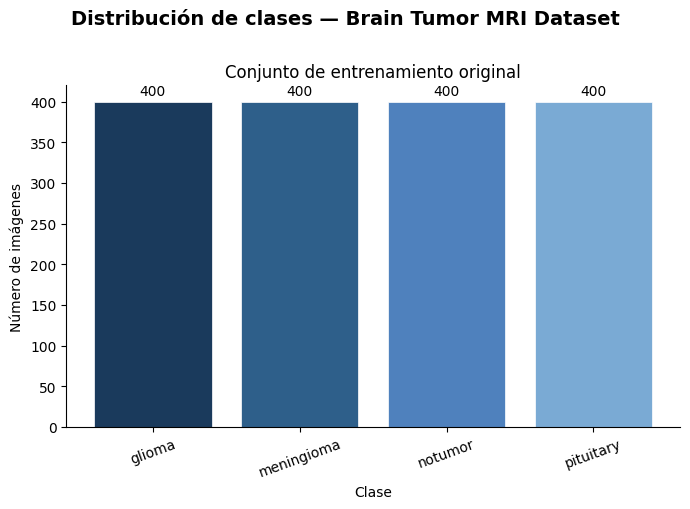

Grafico guardado en Drive.


In [ ]:
# Grafico de barras con distribucion por clase
COLOR_PRINCIPAL = '#4f81bd'
COLORES = ['#1a3a5c', '#2e5f8a', '#4f81bd', '#7aaad4']

fig, axes = plt.subplots(1, 2 if conteo_test else 1, figsize=(14 if conteo_test else 7, 5))
fig.suptitle('Distribución de clases — Brain Tumor MRI Dataset', fontsize=14, fontweight='bold', y=1.01)

# Manejar axes si solo hay un subplot (no hay dir de test)
ax_train = axes[0] if conteo_test else axes

barras = ax_train.bar(conteo_train.keys(), conteo_train.values(), color=COLORES, edgecolor='white', linewidth=0.5)
ax_train.set_title('Conjunto de entrenamiento original', fontsize=12)
ax_train.set_ylabel('Número de imágenes')
ax_train.set_xlabel('Clase')
for barra in barras:
    ax_train.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 5,
            str(int(barra.get_height())), ha='center', va='bottom', fontsize=10)
ax_train.tick_params(axis='x', rotation=20)
ax_train.spines[['top', 'right']].set_visible(False)

if conteo_test:
    ax_test = axes[1]
    barras2 = ax_test.bar(conteo_test.keys(), conteo_test.values(), color=COLORES, edgecolor='white', linewidth=0.5)
    ax_test.set_title('Conjunto de testing original', fontsize=12)
    ax_test.set_ylabel('Número de imágenes')
    ax_test.set_xlabel('Clase')
    for barra in barras2:
        ax_test.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 2,
                str(int(barra.get_height())), ha='center', va='bottom', fontsize=10)
    ax_test.tick_params(axis='x', rotation=20)
    ax_test.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(DIR_PROYECTO / 'eda_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico guardado en Drive.")

### 7.2 Muestras visuales por clase

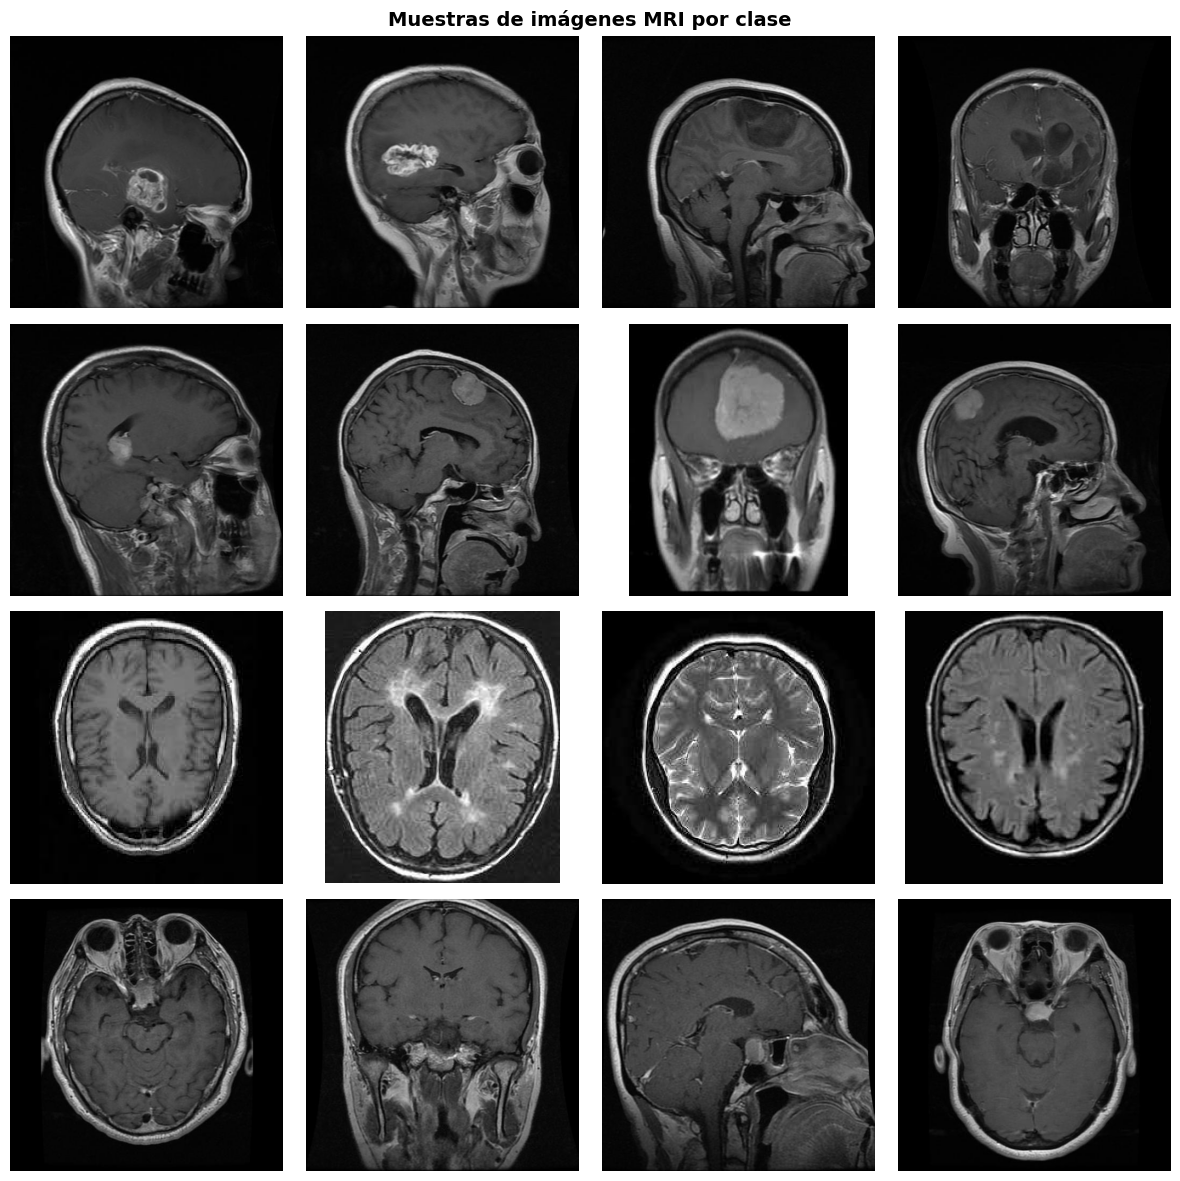

Muestras guardadas en Drive.


In [ ]:
N_MUESTRAS = 4
extensiones = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

fig, axes = plt.subplots(len(CLASES), N_MUESTRAS, figsize=(N_MUESTRAS * 3, len(CLASES) * 3))
fig.suptitle('Muestras de imágenes MRI por clase', fontsize=14, fontweight='bold')

for fila, clase in enumerate(CLASES):
    dir_clase = DIR_TRAIN_ORIGINAL / clase
    imagenes = [f for f in dir_clase.rglob('*') if f.suffix.lower() in extensiones]
    muestras = random.sample(imagenes, min(N_MUESTRAS, len(imagenes)))

    for col, img_path in enumerate(muestras):
        ax = axes[fila][col]
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(clase, fontsize=11, fontweight='bold', rotation=90,
                         labelpad=10, color='#1a3a5c')

plt.tight_layout()
plt.savefig(DIR_PROYECTO / 'eda_muestras_por_clase.png', dpi=120, bbox_inches='tight')
plt.show()
print("Muestras guardadas en Drive.")

### 7.3 Estadísticas de resolución y canales

In [ ]:
estadisticas = {}

for clase in CLASES:
    dir_clase = DIR_TRAIN_ORIGINAL / clase
    imagenes = [f for f in dir_clase.rglob('*') if f.suffix.lower() in extensiones]
    muestra = random.sample(imagenes, min(100, len(imagenes)))

    anchos, altos, canales = [], [], []
    for img_path in muestra:
        try:
            with Image.open(img_path) as img:
                anchos.append(img.width)
                altos.append(img.height)
                canales.append(len(img.getbands()))
        except Exception:
            continue

    estadisticas[clase] = {
        'ancho_min': min(anchos), 'ancho_max': max(anchos), 'ancho_media': np.mean(anchos),
        'alto_min': min(altos),   'alto_max': max(altos),   'alto_media': np.mean(altos),
        'canales_tipicos': Counter(canales).most_common(1)[0][0]
    }

print(f"\n{'Clase':<20} {'Ancho (min/max/med)':<26} {'Alto (min/max/med)':<26} {'Canales'}")
print("-" * 85)
for clase, s in estadisticas.items():
    print(f"{clase:<20} "
          f"{s['ancho_min']:>4}/{s['ancho_max']:>4}/{s['ancho_media']:>6.0f}px    "
          f"{s['alto_min']:>4}/{s['alto_max']:>4}/{s['alto_media']:>6.0f}px    "
          f"{s['canales_tipicos']}")

print("\nNota: todas las imagenes seran redimensionadas a 224x224 px y convertidas a 3 canales RGB.")


Clase                Ancho (min/max/med)        Alto (min/max/med)         Canales
-------------------------------------------------------------------------------------
glioma                233/ 620/   494px     233/ 641/   498px    1
meningioma            200/ 630/   453px     195/ 554/   458px    3
notumor               150/ 680/   305px     168/ 680/   309px    3
pituitary             256/ 512/   507px     256/ 512/   507px    1

Nota: todas las imagenes seran redimensionadas a 224x224 px y convertidas a 3 canales RGB.


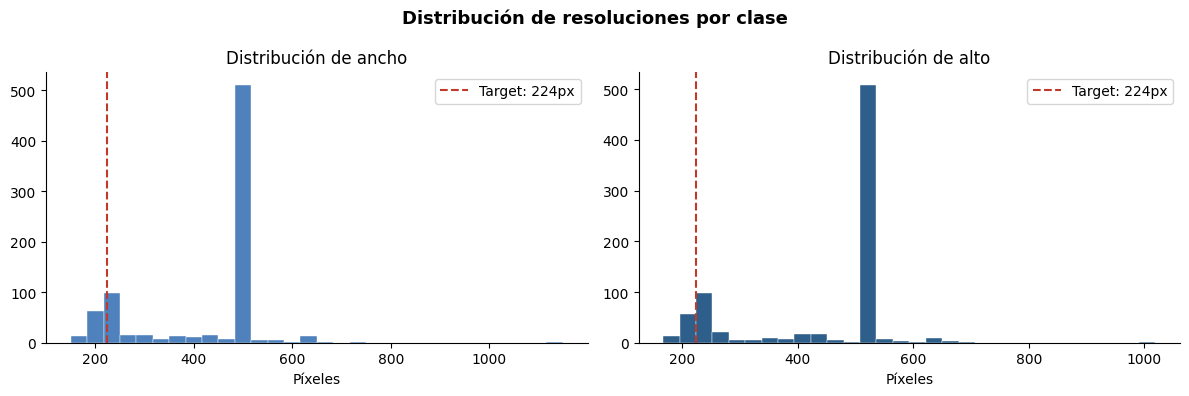

In [ ]:
# Histograma de resoluciones
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribución de resoluciones por clase', fontsize=13, fontweight='bold')

todos_anchos, todos_altos = [], []
for clase in CLASES:
    dir_clase = DIR_TRAIN_ORIGINAL / clase
    imagenes = [f for f in dir_clase.rglob('*') if f.suffix.lower() in {'.jpg','.jpeg','.png'}]
    muestra = random.sample(imagenes, min(200, len(imagenes)))
    for img_path in muestra:
        try:
            with Image.open(img_path) as img:
                todos_anchos.append(img.width)
                todos_altos.append(img.height)
        except Exception:
            pass

axes[0].hist(todos_anchos, bins=30, color=COLOR_PRINCIPAL, edgecolor='white', linewidth=0.3)
axes[0].axvline(224, color='#c0392b', linestyle='--', linewidth=1.5, label='Target: 224px')
axes[0].set_title('Distribución de ancho'); axes[0].set_xlabel('Píxeles')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

axes[1].hist(todos_altos, bins=30, color='#2e5f8a', edgecolor='white', linewidth=0.3)
axes[1].axvline(224, color='#c0392b', linestyle='--', linewidth=1.5, label='Target: 224px')
axes[1].set_title('Distribución de alto'); axes[1].set_xlabel('Píxeles')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(DIR_PROYECTO / 'eda_resoluciones.png', dpi=120, bbox_inches='tight')
plt.show()

### 7.4 Análisis de intensidades de píxel

In [ ]:
# Calcular media y desviacion estandar global del dataset
# Esto confirma si usar estadisticas de ImageNet es una buena aproximacion

todas_imagenes = []
for clase in CLASES:
    dir_clase = DIR_TRAIN_ORIGINAL / clase
    imgs = [f for f in dir_clase.rglob('*') if f.suffix.lower() in {'.jpg','.jpeg','.png'}]
    todas_imagenes.extend(random.sample(imgs, min(75, len(imgs))))

random.shuffle(todas_imagenes)
muestra_300 = todas_imagenes[:300]

medias, desviaciones = [], []
for img_path in muestra_300:
    try:
        img = np.array(Image.open(img_path).convert('RGB'), dtype=np.float32) / 255.0
        medias.append(img.mean(axis=(0,1)))
        desviaciones.append(img.std(axis=(0,1)))
    except Exception:
        pass

media_dataset    = np.mean(medias, axis=0)
desv_dataset     = np.mean(desviaciones, axis=0)
media_imagenet   = np.array([0.485, 0.456, 0.406])
desv_imagenet    = np.array([0.229, 0.224, 0.225])

print("\nEstadisticas del dataset (RGB, normalizado 0-1):")
print(f"  Media real  : {media_dataset.round(3)}")
print(f"  Media ImageNet: {media_imagenet}")
print(f"  Desv. real  : {desv_dataset.round(3)}")
print(f"  Desv. ImageNet: {desv_imagenet}")
print("Conclusión: se usaran las estadisticas de ImageNet para la normalizacion.")



Estadisticas del dataset (RGB, normalizado 0-1):
  Media real  : [0.198 0.198 0.198]
  Media ImageNet: [0.485 0.456 0.406]
  Desv. real  : [0.19 0.19 0.19]
  Desv. ImageNet: [0.229 0.224 0.225]
Conclusión: se usaran las estadisticas de ImageNet para la normalizacion.


## 8. División estratificada del dataset (70 / 15 / 15)

Se combinan primero los conjuntos `Training` y `Testing` originales en un único pool,  
luego se realiza la división estratificada para garantizar proporciones de clase uniformes  
en los tres subconjuntos.


In [ ]:
DIR_POOL = Path('/content/brain_tumor_pool')

print("\nConsolidando imagenes en directorio temporal (pool) para procesar rápido...")
for fuente in [DIR_TRAIN_ORIGINAL, DIR_TEST_ORIGINAL]:
    if fuente is None:
        continue
    for clase_dir in fuente.iterdir():
        if not clase_dir.is_dir():
            continue
        destino_clase = DIR_POOL / clase_dir.name
        destino_clase.mkdir(parents=True, exist_ok=True)
        for img in clase_dir.rglob('*'):
            if img.suffix.lower() in extensiones:
                nuevo_nombre = f"{fuente.name}_{img.name}"
                shutil.copy2(img, destino_clase / nuevo_nombre)


Consolidando imagenes en directorio temporal (pool) para procesar rápido...


In [ ]:
DIR_SPLITS_LOCAL = Path('/content/brain_tumor_splits')

if DIR_SPLITS_LOCAL.exists():
    shutil.rmtree(DIR_SPLITS_LOCAL)

print("Creando splits estratificados (70/15/15)...")
splitfolders.ratio(
    input  = str(DIR_POOL),
    output = str(DIR_SPLITS_LOCAL),
    seed   = SEMILLA,
    ratio  = (0.70, 0.15, 0.15),
    group_prefix = None,
    move = False
)
print("Splits creados exitosamente en disco local.")

Creando splits estratificados (70/15/15)...


Copying files: 1600 files [00:00, 6031.19 files/s]

Splits creados exitosamente en disco local.


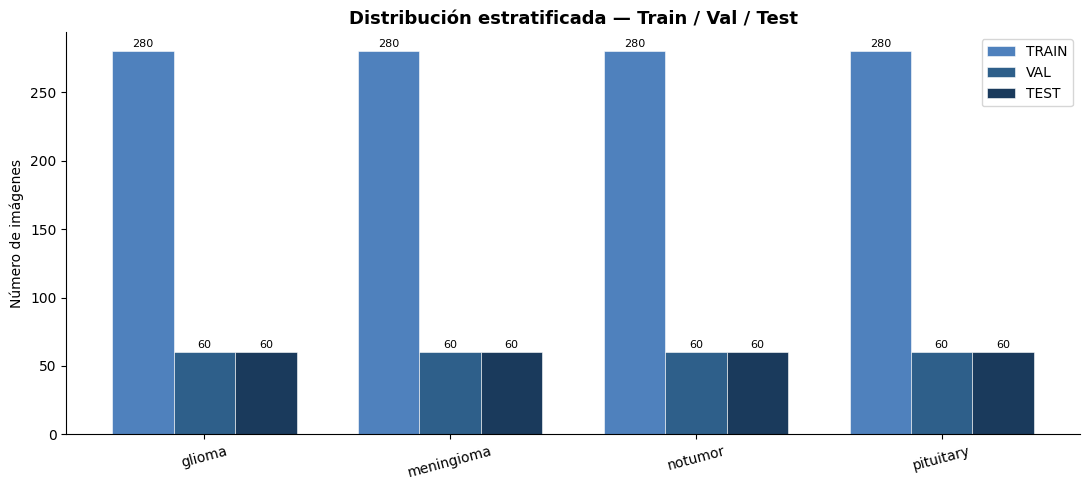

In [ ]:
# Visualizar distribución final de los tres splits
splits_data = {}
for split in ['train', 'val', 'test']:
    dir_split = DIR_SPLITS_LOCAL / split
    if dir_split.exists():
        splits_data[split] = {
            d.name: sum(1 for f in d.rglob('*') if f.suffix.lower() in extensiones)
            for d in sorted(dir_split.iterdir()) if d.is_dir()
        }

clases_splits = sorted(next(iter(splits_data.values())).keys())
x = np.arange(len(clases_splits))
ancho = 0.25
colores_splits = [COLOR_PRINCIPAL, '#2e5f8a', '#1a3a5c']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (split, datos) in enumerate(splits_data.items()):
    valores = [datos.get(c, 0) for c in clases_splits]
    barras = ax.bar(x + i * ancho, valores, ancho, label=split.upper(),
                    color=colores_splits[i], edgecolor='white', linewidth=0.4)
    for barra in barras:
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 2,
                str(int(barra.get_height())), ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + ancho)
ax.set_xticklabels(clases_splits, rotation=15)
ax.set_ylabel('Número de imágenes')
ax.set_title('Distribución estratificada — Train / Val / Test', fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(DIR_PROYECTO / 'eda_splits_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Guardar splits en Google Drive

In [ ]:
DIR_SPLITS_DRIVE = DIR_PROYECTO / 'brain_tumor_splits'

if DIR_SPLITS_DRIVE.exists():
    print(f"\nEl directorio de splits ya existe en Drive: {DIR_SPLITS_DRIVE}")
    print("Si deseas regenerarlo, borralo manualmente y vuelve a ejecutar este script.")
else:
    print(f"\nCopiando splits definitivos a Google Drive ({DIR_SPLITS_DRIVE})...")
    shutil.copytree(DIR_SPLITS_LOCAL, DIR_SPLITS_DRIVE)
    print("Copia completada.")


Copiando splits definitivos a Google Drive (/content/drive/MyDrive/Deep Learning/deep_learning_tumor_mri/brain_tumor_splits)...
Copia completada.


In [ ]:
# Guardar configuracion del dataset en JSON para que los notebooks 02 y 03 la lean
config = {
    "dir_splits"   : str(DIR_SPLITS_DRIVE),
    "clases"       : sorted([d.name for d in (DIR_SPLITS_DRIVE / 'train').iterdir() if d.is_dir()]),
    "semilla"      : SEMILLA,
    "img_size"     : 224,
    "media_norm"   : [0.485, 0.456, 0.406],
    "desv_norm"    : [0.229, 0.224, 0.225],
    "conteo_splits": {
        split: {
            d.name: sum(1 for f in d.rglob('*') if f.suffix.lower() in {'.jpg','.jpeg','.png'})
            for d in sorted((DIR_SPLITS_DRIVE / split).iterdir()) if d.is_dir()
        }
        for split in ['train', 'val', 'test']
    }
}

ruta_config = DIR_PROYECTO / 'dataset_config.json'
with open(ruta_config, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)


## 10. Resumen y próximos pasos

In [ ]:
print("\n" + "=" * 60)
print("  Resumen de Exploración del Dataset")
print("=" * 60)

with open(ruta_config) as f:
    cfg = json.load(f)

print(f"\nClases encontradas  : {cfg['clases']}")
print(f"Tamaño de entrada   : {cfg['img_size']}x{cfg['img_size']} px")

print("\nDistribución de splits final:")
for split, conteo in cfg['conteo_splits'].items():
    total = sum(conteo.values())
    print(f"  {split.upper():<6} → total={total}")
    for clase, n in conteo.items():
        print(f"           {clase:<20} {n:>5} ({n/total*100:.1f}%)")


  RESUMEN — Notebook 01: Exploración del Dataset

Clases encontradas  : ['glioma', 'meningioma', 'notumor', 'pituitary']
Tamaño de entrada   : 224x224 px

Distribución de splits final:
  TRAIN  → total=1120
           glioma                 280 (25.0%)
           meningioma             280 (25.0%)
           notumor                280 (25.0%)
           pituitary              280 (25.0%)
  VAL    → total=240
           glioma                  60 (25.0%)
           meningioma              60 (25.0%)
           notumor                 60 (25.0%)
           pituitary               60 (25.0%)
  TEST   → total=240
           glioma                  60 (25.0%)
           meningioma              60 (25.0%)
           notumor                 60 (25.0%)
           pituitary               60 (25.0%)

Siguientes pasos:
  → Abrir 02_entrenamiento_ViT.ipynb
  → Abrir 03_entrenamiento_ConvNeXt.ipynb
